# Online learning for an MLP using extended Kalman filtering

*This example is adapted from the [dynamax notebook of the same name](https://probml.github.io/dynamax/notebooks/nonlinear_gaussian_ssm/ekf_mlp.html).*

We perform sequential (recursive) Bayesian inference for the parameters of a multi layer perceptron (MLP)
using the extended Kalman filter.
To do this, we treat the parameters of the model as the unknown hidden states.
We assume that these are approximately constant over time (we add a small amount of Gaussian drift,
for numerical stability.)

The model has the following form

\begin{align*}
\theta_t &=  \theta_{t-1} + q_t, \; q_t \sim \mathcal{N}(0, 10^{-4} I)  \\
y_t &= h(\theta_t, x_t) + r_t, \; r_t \sim \mathcal{N}(0, \sigma^2)
\end{align*}

This is a NLG-SSM, where $h$ is the nonlinear observation model.
For details, see sec 17.5.2 of [Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html).

> **Backend note.** This example uses `filter_source="cd_dynamax"`, which provides a Jacobian-based EKF (the same algorithm as dynamax). The `cuthbert` backend used elsewhere in this section implements a Taylor/Laplace log-density filter that is less suited to this high-dimensional nonlinear-observation problem.

## Setup

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from flax import nnx
from jax import vmap
from jax.flatten_util import ravel_pytree

import dynestyx as dsx
from dynestyx import DynamicalModel
from dynestyx.inference.filters import EKFConfig, Filter
from dynestyx.models import GaussianObservation, GaussianStateEvolution

## Data

Generate noisy observations of a nonlinear function,
\begin{align*}
y_i &\sim \mathcal{N}(f(x_i), \sigma_y^2) \\
f(x) &= x - 10 \cos(x) \sin(x) + x^3
\end{align*}

where the inputs or covariates $x_i$ are set to,
\begin{align*}
x_i &\sim \mathcal{N}\left(-3 + 6 \tfrac{i}{n}, \sigma_x^2 \right)
\end{align*}

Here, we have $n=200$ observations with noise standard deviations $\sigma_x = 0.1$ and $\sigma_y = 3.0$.

The indices of the training pairs $(x_i, y_i)$ are permuted before training so that the network "sees" data points in random order.

In [2]:
def sample_observations(key, f, x_min, x_max, x_std=0.1, y_std=3.0, num_obs=200):
    """Sample noisy (x, y) pairs from `f`, returned in a random order."""
    x_key, y_key, shuffle_key = jr.split(key, 3)
    x = jnp.linspace(x_min, x_max, num_obs) + jr.normal(x_key, (num_obs,)) * x_std
    y = f(x) + jr.normal(y_key, (num_obs,)) * y_std
    order = jr.permutation(shuffle_key, num_obs)
    return x[order], y[order]


f = lambda x: x - 10 * jnp.cos(x) * jnp.sin(x) + x**3
y_std = 3.0
inputs, emissions = sample_observations(
    jr.PRNGKey(1), f, x_min=-3, x_max=3, y_std=y_std
)

## Neural network

We aim to approximate the true data generating function, $f(x)$, with a parametric approximation, $h(\theta, x)$, where $\theta$ are the parameters and $x$ are the inputs. We use a simple feedforward neural network &mdash; a.k.a. multi-layer perceptron (MLP) &mdash; with sigmoidal nonlinearities. Here, $\theta$ corresponds to the flattened vector of all the weights from all the layers of the model.

In [3]:
class MLP(nnx.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, *, rngs):
        self.hidden = nnx.Linear(in_dim, hidden_dim, rngs=rngs)
        self.out = nnx.Linear(hidden_dim, out_dim, rngs=rngs)

    def __call__(self, x):
        return self.out(nnx.sigmoid(self.hidden(x)))


# The EKF treats the flattened network weights as the latent state, so we split
# the model into a static graph definition and a flat parameter vector, and
# provide an `apply` that rebuilds the model from a flat vector to evaluate it.
model = MLP(1, 6, 1, rngs=nnx.Rngs(0))
graphdef, params = nnx.split(model, nnx.Param)
flat_params, unravel_params = ravel_pytree(params)


def apply_fn(flat_params, x):
    model = nnx.merge(graphdef, unravel_params(flat_params))
    return model(jnp.atleast_1d(x))

## Online inference

Here we demonstrate how to estimate the model parameters in **online** fashion using the Extended Kalman Filter (EKF). As described above, the idea is to think of the latent state as the parameter estimate at time $t$, after seeing $t$ data points. Each new data point provides an update of the parameter estimate, and the parameters are allowed to drift very slightly from one data point to the next.

The dynamics function is the identity (the parameters are approximately constant), and the emission function is the MLP forward pass. Each input $x_t$ is supplied to the observation as a control.

In [4]:
state_dim = flat_params.size  # the flattened MLP weights
emission_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(flat_params, jnp.eye(state_dim) * 100),
    state_evolution=GaussianStateEvolution(
        F=lambda x, u, t_now, t_next: x, cov=jnp.eye(state_dim) * 1e-4
    ),
    observation_model=GaussianObservation(
        h=lambda x, u, t: apply_fn(x, u[0]), R=jnp.eye(emission_dim) * y_std**2
    ),
    control_dim=1,
)

obs_times = jnp.arange(float(inputs.size))

# Run EKF on the training set to train the MLP
with Filter(
    filter_config=EKFConfig(
        filter_source="cd_dynamax",
        record_filtered_states_mean=True,
        record_filtered_states_cov=True,
    )
):
    ekf_post = dsx.condition(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=emissions[:, None],
        ctrl_times=obs_times,
        ctrl_values=inputs[:, None],
    )

w_means = ekf_post.states.filtered_means
w_covs = ekf_post.states.filtered_covariances

/Users/therash/Documents/dev/dynestyx/dynestyx/inference/integrations/cd_dynamax/discrete_filter.py:120: UserWarning: cd_dynamax discrete-time filters ignore absolute time arguments in GaussianStateEvolution/GaussianObservation. For genuinely time-varying discrete-time models, use a filter/backend that preserves absolute time semantics, such as EnKFConfig(filter_source='cuthbert').
  params_nl = gaussian_to_nlgssm_params(dynamics)


## Plot results

Let $h(\theta, x)$ denote the function approximation produced by an MLP with parameters $\theta$. If the parameters are random, $\theta \sim \mathcal{N}(\mu, \Sigma)$, then the resulting function $h$ is random as well. We can visualize the distribution over functions by drawing samples of $\theta$ and plotting the resulting function for each parameter sample.

The helper function below plots the mean function in blue, and also plots the function for various parameter samples $h(\theta^{(j)}, x)$ where $\theta^{(j)} \sim \mathcal{N}(\mu, \Sigma)$. These samples give a sense of the uncertainty of $h$ under the distribution of parameters.

In [5]:
def plot_mlp_prediction(
    key, h, obs, x_grid, w_mean, w_cov, ax, num_samples=100, y_lim=(-30, 30)
):
    # Plot observations (training set) and the true function.
    ax.plot(
        obs[0], obs[1], "ok", fillstyle="none", ms=4, alpha=0.5, label="observation"
    )
    ax.plot(x_grid, vmap(f)(x_grid), linewidth=2, color="k", label=r"$f(x)$")

    # Sample weights from the filtering distribution and evaluate the MLP for each.
    w_samples = jr.multivariate_normal(key, w_mean, w_cov, (num_samples,))
    y_samples = vmap(vmap(h, in_axes=(None, 0)), in_axes=(0, None))(w_samples, x_grid)
    for j, y_sample in enumerate(y_samples):
        ax.plot(
            x_grid,
            y_sample,
            color="gray",
            alpha=0.07,
            label=r"$h(\theta^{(j)}, x)$" if j == 0 else None,
        )
    ax.plot(x_grid, y_samples.mean(axis=0), linewidth=1.5, label=r"$h(\mu, x)$")

    ax.set_ylim(y_lim)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$h(\theta, x)$")
    ax.legend(loc=4, borderpad=0.5, handlelength=4, fancybox=False, edgecolor="k")

### Plot the estimated function after seeing different numbers of data points

Now we use the function above to plot the distribution over functions, $h$, under the filtering distribution of the parameters $\theta_t \sim \mathcal{N}(\mu_{t|t}, \Sigma_{t|t})$, where the mean and covariance are from the extended Kalman filter above. These distributions capture the uncertainty in $h$ after seeing $t$ data points.

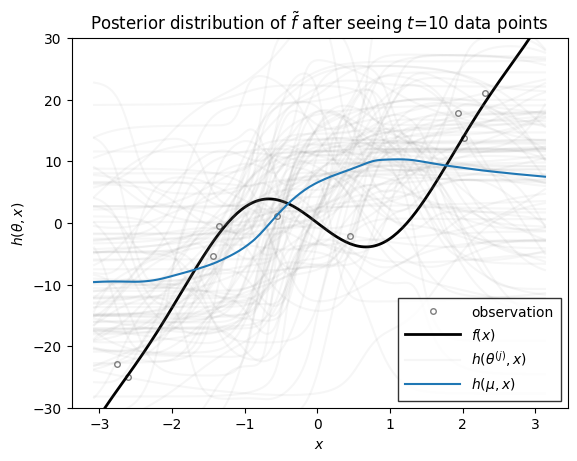

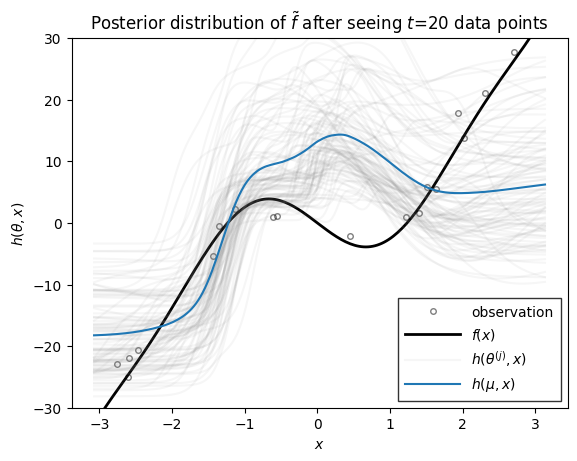

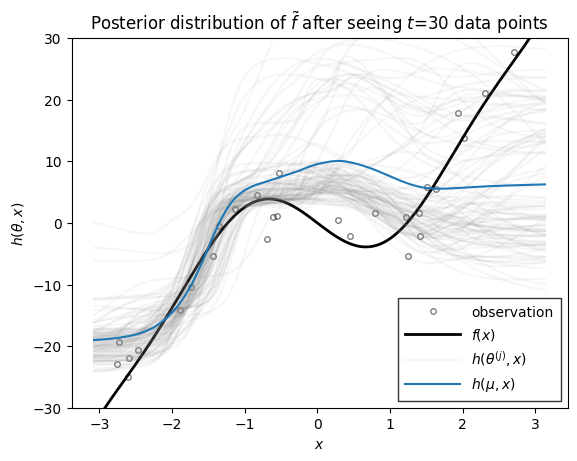

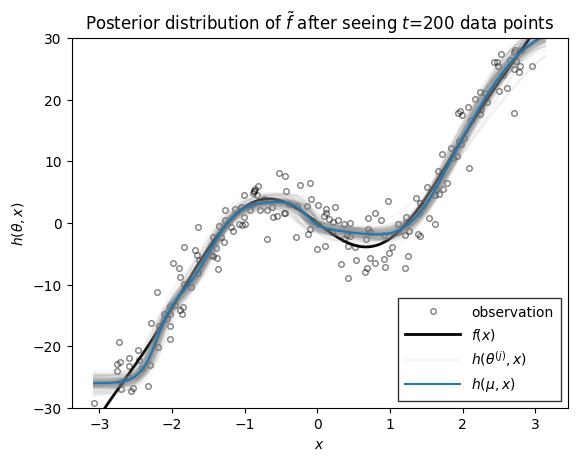

In [6]:
inputs_grid = jnp.linspace(inputs.min(), inputs.max(), len(inputs))
for step in [10, 20, 30, 200]:
    fig, ax = plt.subplots()
    plot_mlp_prediction(
        jr.PRNGKey(step),
        apply_fn,
        (inputs[:step], emissions[:step]),
        inputs_grid,
        w_means[step - 1],
        w_covs[step - 1],
        ax,
    )
    ax.set_title(
        rf"Posterior distribution of $\tilde{{f}}$ after seeing $t$={step} data points"
    )
    plt.show()

## Conclusion

As you can see, as the number of data points grows, the posterior distribution over functions concentrates. At early stages, the EKF appears to be overly confident in its predictions, sometimes in the face of data. By the time 200 data points have been observed, however, the estimate does a good job of approximating the true data-generating function!